In [23]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [24]:
df = pd.read_csv('income_clustering.csv')

df = df[['Age','Income($)']]


In [25]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled = pd.DataFrame(df_scaled,columns = df.columns)

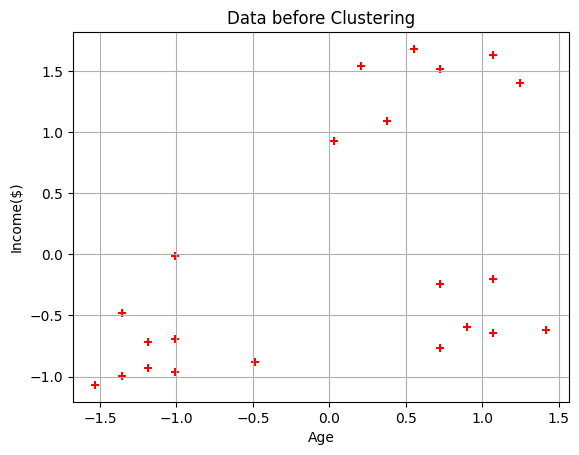

In [26]:
plt.scatter(df_scaled['Age'],df_scaled['Income($)'],color = 'r',marker='+')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.title('Data before Clustering')
plt.grid()
plt.show()

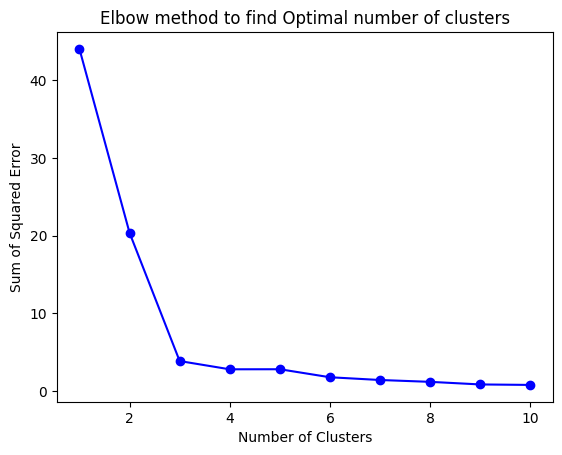

In [27]:
inertia = []

for i in range(1,11):
    km = KMeans(n_clusters=i)
    km.fit(df_scaled)
    inertia.append(km.inertia_)

plt.plot(np.array(range(1,11)),inertia,color='b',marker='o')
plt.title('Elbow method to find Optimal number of clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Sum of Squared Error')
plt.show()

In [28]:
km = KMeans(n_clusters=3)
df_scaled['Cluster'] = km.fit_predict(df_scaled)

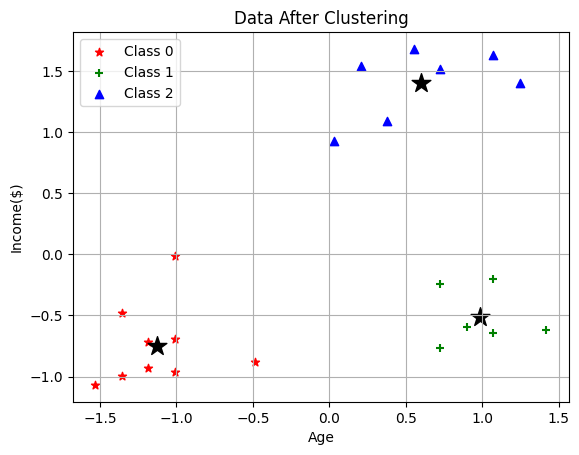

In [29]:
colors = ["r", "g", "b"]
markers = ["*", "+", "^"]

for i in range(3):
    class_points = df_scaled[df_scaled['Cluster'] == i]
    plt.scatter(class_points['Age'],class_points['Income($)'],marker=markers[i],color=colors[i],label=f"Class {i}")

centeroids = km.cluster_centers_
plt.scatter(centeroids[:,0],centeroids[:,1],s=200,marker='*',color='black')
plt.legend()
plt.title('Data After Clustering')
plt.xlabel('Age')
plt.ylabel('Income($)')
plt.grid()
plt.show()